# **Group Project 2**
# **Submitted by: Vikas Gautam, Vahid Nikoofard**
# **Project group:  9284**
# **Date: 11/5/2025**

In [41]:
%pip install -U yfinance PyPortfolioOpt
!pip install dataframe_image
import dataframe_image as dfi
from google.colab import files
import pandas as pd
import numpy as np
import yfinance as yf
import pathlib
from pandas_datareader.data import DataReader
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize
import plotly.express as px
import matplotlib.pyplot as plt
from pypfopt import BlackLittermanModel, black_litterman, plotting

# Step 1

To compose out portfolio and achive a high diversification we decicded to pick, at least, three stocks from each sector of S&P500 (a high cap, a middle cap and one small cap) plus Gold and Bitcoin.

In [42]:
TRAIN_START, TRAIN_END = "2021-01-04", "2024-12-31"
TEST_START,  TEST_END  = "2025-01-06", "2025-05-08"
TRADING_DAYS     = 252
CACHE_DIR        = pathlib.Path("data_cache"); CACHE_DIR.mkdir(exist_ok=True)

# ---- universe --------------------------------------------------------------------
TICKERS = [
    # Materials
    "LIN", "APD", "ALB",
    # Communication Services
    "META", "CMCSA", "FOXA", "GOOGL",
    # Energy
    "XOM", "COP", "APA", 'CVX',
    # Financials
    "JPM", "PNC", "LNC", "BRK-B", 'V',
    # Industrials
    "CAT", "UPS", "CARR", 'GE',
    # Information Technology
    "NVDA", "SNPS", "ZS", 'AAPL', 'MSFT',
    # Consumer Staples
    "PG", "KMB", "TAP", 'COST',
    # Utilities
    "NEE", "DUK", "AES",
    # Health Care
    "UNH", "MDT", "BAX", 'LLY',
    # Consumer Discretionary
    "AMZN", "NKE", "ETSY", "TSLA",
    # Real Estate
    "PLD", "AMT", "AVB",
]

EXTRA_ASSETS = ["GC=F", "BTC-USD"]
TICKERS      = TICKERS + EXTRA_ASSETS


In [43]:
# ------------------------------------------------------------------------------------
# 1. Helper to download or load cached prices
# ------------------------------------------------------------------------------------
def get_prices(tickers, start, end, tag):
    p_path = CACHE_DIR / f"prices_{tag}_{start}_{end}.parquet"
    if p_path.exists():
        return pd.read_parquet(p_path)
    px = (
        yf.download(tickers, start=start, end=end, progress=False)["Close"]
          .dropna(axis=1, how='all')
    )
    px.to_parquet(p_path)
    return px

In [44]:
def save_df_as_image(df, filename='filtered_weights.png', dpi=200):
    fig, ax = plt.subplots(figsize=(len(df.columns)*2, len(df)*0.5 + 1))
    ax.axis('off')
    table = ax.table(cellText=df.round(4).values,
                     colLabels=df.columns,
                     rowLabels=df.index,
                     cellLoc='center',
                     loc='center')
    table.scale(1, 1.5)
    plt.tight_layout()
    plt.savefig(filename, dpi=dpi)
    plt.close()



In [45]:
# ------------------------------------------------------------------------------------
# 2. Fetch training & test windows
# ------------------------------------------------------------------------------------

prices_train = get_prices(TICKERS, TRAIN_START, TRAIN_END, "train").dropna(axis=0, how='any')
prices_test  = get_prices(TICKERS, TEST_START,  TEST_END,  "test").dropna(axis=0, how='any')


# Convert to log-returns (drop first row)
returns_train = np.log(prices_train / prices_train.shift()).dropna()
returns_test  = np.log(prices_test  / prices_test.shift()).dropna()

# Calculate mean returns and covariance matrix
mean_returns_train = returns_train.mean()
mean_returns_test  = returns_test.mean()

# ================================================================
# 4. Risk-free daily series from FRED (DGS2)
# ================================================================
rf_all = (
    DataReader("DGS2", "fred", TRAIN_START, TEST_END)   # % p.a.
      .div(100.0)                                       # to decimal p.a.
      .ffill()                                          # fill Fed/market holidays
)

rf_daily_train = (
    rf_all["DGS2"]
    .reindex(returns_train.index, method="ffill")  # preenche valores ausentes
    / TRADING_DAYS
)
rf_daily_test = (
    rf_all["DGS2"]
    .reindex(returns_test.index, method="ffill")
    / TRADING_DAYS
)


rf_mean_train = rf_daily_train.mean()
rf_mean_test  = rf_daily_test.mean()


## plot the normalized prices_train and prices_test

In [46]:
# plot the normalized prices_train and prices_test

prices_train_norm = prices_train / prices_train.iloc[0]
prices_test_norm = prices_test / prices_test.iloc[0]
px.line(prices_train_norm, title='Train prices').show()
# px.line(prices_test_norm, title='Test prices').show()


In [47]:
 px.line(prices_test_norm, title='Test prices').show()


Here rwe calculate the covariance matrix of the asset returns in two way to make sure our estimation is robust.

In [48]:
# ------------------------------------------------------------------
# Covariance estimators: sample and Ledoit–Wolf shrinkage
# ------------------------------------------------------------------

# ---------- (1) sample covariance ---------------------------------
Sigma_sample = returns_train.cov(ddof=1)


# ---------- (2) Ledoit–Wolf shrinkage -----------------------------
lw = LedoitWolf(store_precision=False, assume_centered=False)
lw.fit(returns_train.values)           # expects ndarray
Sigma_shrinkage = pd.DataFrame(
    lw.covariance_,
    index=returns_train.columns,
    columns=returns_train.columns
)


# ---------- optional: save to disk or inspect ---------------------
Sigma_sample.to_csv("cov_sample.csv", float_format="%.6e")
Sigma_shrinkage.to_csv("cov_shrink_LW.csv", float_format="%.6e")



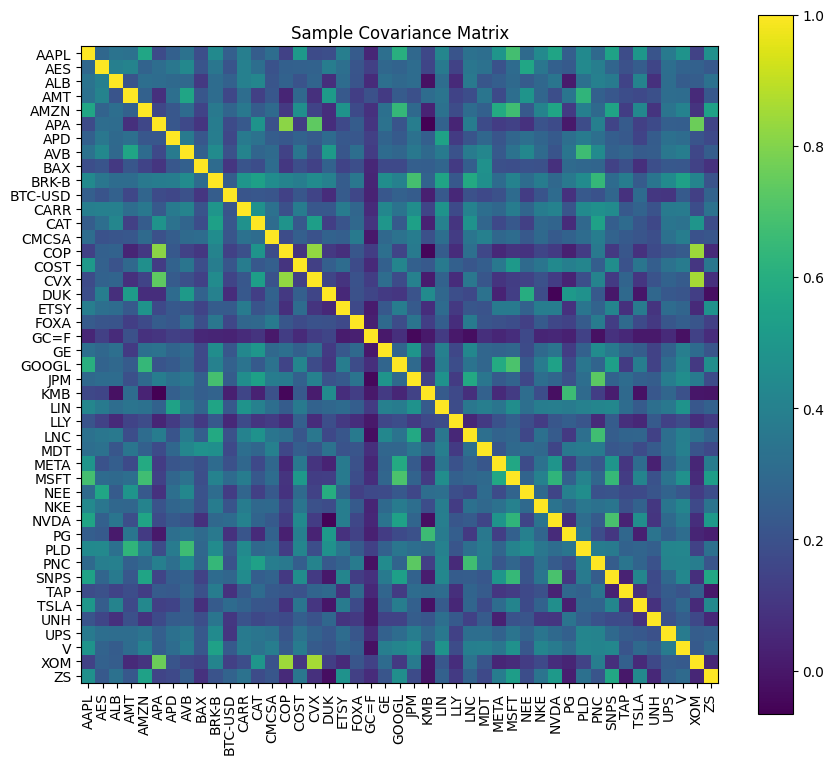

In [49]:
ax = plotting.plot_covariance(Sigma_sample, plot_correlation=True)
ax.figure.set_size_inches(9, 9)
ax.set_title("Sample Covariance Matrix")
plt.show()

##Sigma_sample Estimator

In [50]:
Sigma_sample

Ticker,AAPL,AES,ALB,AMT,AMZN,APA,APD,AVB,BAX,BRK-B,...,PLD,PNC,SNPS,TAP,TSLA,UNH,UPS,V,XOM,ZS
Ticker,,,,,,,,,,,,,,,,,,,,,
AAPL,0.000280,0.000105,0.000185,0.000092,0.000210,0.000092,0.000072,0.000077,0.000056,0.000078,...,0.000124,0.000088,2.018120e-04,5.014725e-05,3.129678e-04,0.000052,0.000105,0.000115,4.241663e-05,2.752775e-04
AES,0.000105,0.000469,0.000277,0.000146,0.000131,0.000209,0.000127,0.000130,0.000081,0.000081,...,0.000159,0.000149,1.344795e-04,7.211840e-05,2.029623e-04,0.000050,0.000116,0.000084,1.001424e-04,1.763593e-04
ALB,0.000185,0.000277,0.001060,0.000113,0.000232,0.000312,0.000160,0.000133,0.000063,0.000108,...,0.000179,0.000229,2.623626e-04,8.074567e-05,5.012007e-04,0.000039,0.000172,0.000113,1.410370e-04,3.800994e-04
AMT,0.000092,0.000146,0.000113,0.000273,0.000097,0.000041,0.000088,0.000128,0.000064,0.000055,...,0.000175,0.000076,8.037339e-05,5.068636e-05,1.053233e-04,0.000047,0.000088,0.000073,1.746258e-05,1.322453e-04
AMZN,0.000210,0.000131,0.000232,0.000097,0.000495,0.000111,0.000081,0.000094,0.000057,0.000086,...,0.000147,0.000118,2.713476e-04,4.766472e-05,3.599691e-04,0.000030,0.000129,0.000130,3.651380e-05,4.233849e-04
APA,0.000092,0.000209,0.000312,0.000041,0.000111,0.000947,0.000112,0.000072,0.000054,0.000125,...,0.000095,0.000214,1.040508e-04,1.221933e-04,1.574421e-04,0.000077,0.000134,0.000110,4.115395e-04,1.647142e-04
APD,0.000072,0.000127,0.000160,0.000088,0.000081,0.000112,0.000268,0.000084,0.000065,0.000067,...,0.000103,0.000094,9.082469e-05,6.299966e-05,9.257354e-05,0.000059,0.000091,0.000073,6.035965e-05,9.819985e-05
AVB,0.000077,0.000130,0.000133,0.000128,0.000094,0.000072,0.000084,0.000191,0.000063,0.000066,...,0.000156,0.000109,8.087762e-05,6.535619e-05,1.245789e-04,0.000050,0.000084,0.000077,3.900992e-05,1.198184e-04
BAX,0.000056,0.000081,0.000063,0.000064,0.000057,0.000054,0.000065,0.000063,0.000308,0.000057,...,0.000085,0.000087,5.494769e-05,5.715228e-05,5.079396e-05,0.000049,0.000068,0.000056,4.475251e-05,5.265150e-05


In [51]:
Sigma_shrinkage

Ticker,AAPL,AES,ALB,AMT,AMZN,APA,APD,AVB,BAX,BRK-B,...,PLD,PNC,SNPS,TAP,TSLA,UNH,UPS,V,XOM,ZS
Ticker,,,,,,,,,,,,,,,,,,,,,
AAPL,0.000283,0.000103,0.000182,0.000090,0.000206,0.000090,0.000071,0.000076,0.000055,0.000077,...,0.000122,0.000086,1.982250e-04,4.925594e-05,3.074052e-04,5.106342e-05,0.000103,0.000113,4.166272e-05,2.703848e-04
AES,0.000103,0.000468,0.000272,0.000144,0.000129,0.000205,0.000125,0.000127,0.000079,0.000080,...,0.000156,0.000146,1.320893e-04,7.083659e-05,1.993549e-04,4.925475e-05,0.000114,0.000083,9.836246e-05,1.732247e-04
ALB,0.000182,0.000272,0.001049,0.000111,0.000228,0.000306,0.000157,0.000130,0.000062,0.000106,...,0.000176,0.000225,2.576994e-04,7.931052e-05,4.922925e-04,3.809611e-05,0.000169,0.000111,1.385302e-04,3.733436e-04
AMT,0.000090,0.000144,0.000111,0.000276,0.000096,0.000040,0.000086,0.000126,0.000063,0.000054,...,0.000172,0.000075,7.894486e-05,4.978547e-05,1.034513e-04,4.606520e-05,0.000087,0.000072,1.715220e-05,1.298948e-04
AMZN,0.000206,0.000129,0.000228,0.000096,0.000494,0.000109,0.000079,0.000092,0.000056,0.000085,...,0.000145,0.000115,2.665248e-04,4.681754e-05,3.535711e-04,2.962757e-05,0.000127,0.000128,3.586481e-05,4.158598e-04
APA,0.000090,0.000205,0.000306,0.000040,0.000109,0.000938,0.000110,0.000071,0.000053,0.000123,...,0.000093,0.000210,1.022014e-04,1.200215e-04,1.546438e-04,7.598937e-05,0.000132,0.000108,4.042249e-04,1.617866e-04
APD,0.000071,0.000125,0.000157,0.000086,0.000079,0.000110,0.000271,0.000082,0.000063,0.000066,...,0.000102,0.000092,8.921039e-05,6.187992e-05,9.092816e-05,5.793141e-05,0.000089,0.000071,5.928684e-05,9.645447e-05
AVB,0.000076,0.000127,0.000130,0.000126,0.000092,0.000071,0.000082,0.000195,0.000062,0.000065,...,0.000153,0.000107,7.944012e-05,6.419457e-05,1.223646e-04,4.911346e-05,0.000082,0.000075,3.831657e-05,1.176888e-04
BAX,0.000055,0.000079,0.000062,0.000063,0.000056,0.000053,0.000063,0.000062,0.000310,0.000056,...,0.000084,0.000086,5.397106e-05,5.613647e-05,4.989116e-05,4.765188e-05,0.000067,0.000055,4.395709e-05,5.171569e-05


## Ledoit–Wolf shrinkage estimator

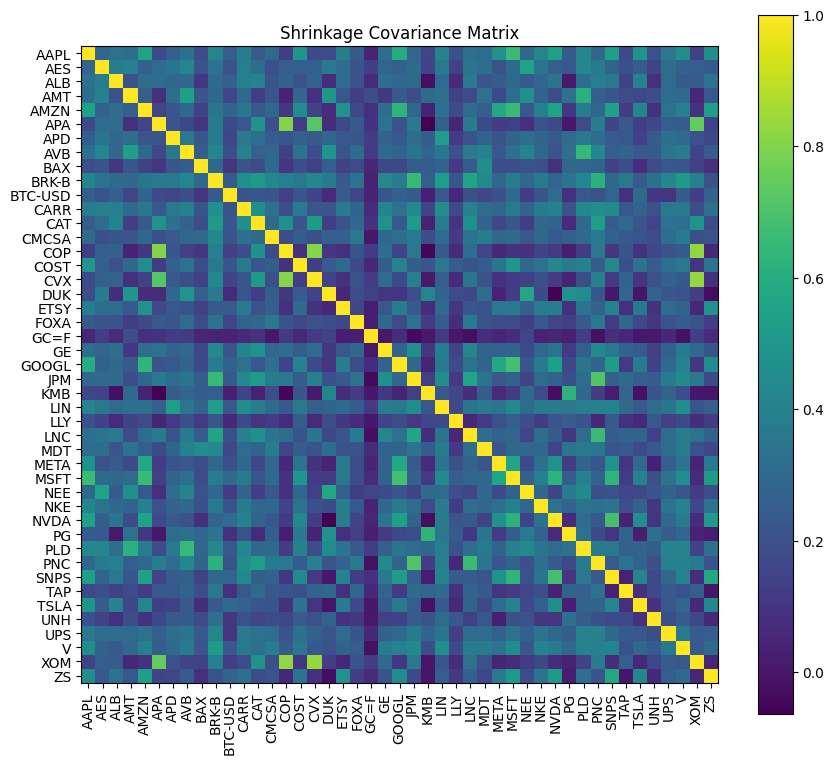

In [52]:
ax = plotting.plot_covariance(Sigma_shrinkage, plot_correlation=True)
ax.figure.set_size_inches(9, 9)
ax.set_title("Shrinkage Covariance Matrix")
plt.show()

# Step 2

In [53]:
# ---------- helper : negative Sharpe  ---------------------------------
def neg_sharpe(w, mu, Σ, rf):
    port_mu  = w @ mu - rf          # daily excess return
    port_sig = np.sqrt(w @ Σ @ w)
    return - port_mu / port_sig

def mvo_weights(mu, Σ, rf, w_min=0.0, w_max=1.0):
    """Long-only max-Sharpe (SLSQP) with upper weight bound *w_max*."""
    n = len(mu)
    bounds = [(w_min, w_max)]*n
    cons   = {'type':'eq', 'fun': lambda w: w.sum() - 1}
    w0     = np.repeat(1/n, n)      # initial guess
    res = minimize(neg_sharpe, w0, args=(mu, Σ, rf),
                   method='SLSQP', bounds=bounds, constraints=cons)
    if not res.success:
        raise RuntimeError(res.message)
    return res.x


In [54]:
# === Step 4: Optimization ===
num_assets = len(TICKERS)
w_min = 0.0
w_max = 0.35

initial_weights = np.ones(num_assets) / num_assets

constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}

weights_sample = mvo_weights(mean_returns_train, Sigma_sample, rf_mean_train, w_min, w_max)

weights_shrinkage = mvo_weights(mean_returns_train, Sigma_shrinkage, rf_mean_train, w_min, w_max)

weights_sample   = pd.Series(weights_sample.round(3), index=TICKERS,
                             name='Sample')
weights_shrinkage = pd.Series(weights_shrinkage.round(3), index=TICKERS,
                              name='Shrinkage')
weights = pd.concat([weights_sample, weights_shrinkage], axis=1)


display(weights.round(3))




,Sample,Shrinkage
LIN,0.000,0.000
APD,0.000,0.000
ALB,0.000,0.000
META,0.000,0.000
CMCSA,0.000,0.000
FOXA,0.000,0.000
GOOGL,0.000,0.000
XOM,0.000,0.000
COP,0.000,0.000
APA,0.000,0.000


In [55]:
# your DataFrame with columns: 'sample' and 'shrinkage'
filtered_df = weights[(weights['Sample'] > 0) | (weights['Shrinkage'] > 0)]
print (filtered_df)

      Sample  Shrinkage
V      0.107      0.109
NVDA   0.103      0.097
SNPS   0.079      0.082
KMB    0.347      0.346
MDT    0.122      0.124
GC=F   0.243      0.242


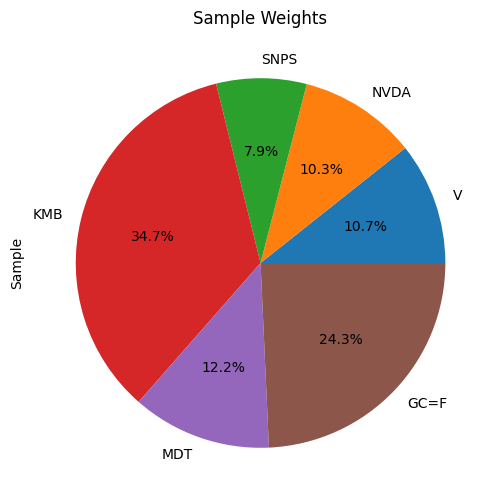

In [56]:
# plot just non zero weights
weights_sample[weights_sample > 0].plot.pie(figsize=(6,6), autopct='%1.1f%%')
plt.title('Sample Weights')
plt.show()

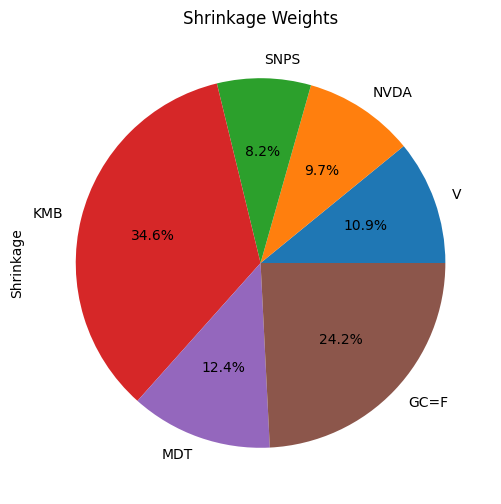

In [57]:
weights_shrinkage[weights_shrinkage > 0].plot.pie(figsize=(6,6), autopct='%1.1f%%')
plt.title('Shrinkage Weights')
plt.show()


As the weights of two portfolios are very similar we will stick to the shrinkage covariance. The reason for this similarity is that our portfolio is not too big and we have enough data points compared to the number of the securities.

In [58]:
# ================================================================
# Evaluate in-sample (train) and out-of-sample (test) performance
# ================================================================

def portfolio_stats(w, rets, rf_daily):
    """Return μ, σ, Sharpe (all annualised) plus total return."""
    excess = rets.sub(rf_daily, axis=0)
    port_excess = excess @ w
    port_total  = rets @ w
    mu  = port_excess.mean()*252
    sig = port_total.std()*np.sqrt(252)
    sharpe = mu / sig
    tot_ret = (1 + port_total).prod() - 1
    return pd.Series([mu, sig, sharpe, tot_ret],
                     index=['μ_ann','σ_ann','Sharpe','TotalReturn'])

def contrib_to_risk(w, Σ):
    """% contribution of each asset to portfolio variance."""
    port_var = w @ Σ @ w
    mrc      = Σ @ w                           # marginal risk contrib
    rc       = w * mrc
    return rc / port_var                       # sums to 1

# ---- stats ------------------------------------------------------
stat_train_samp = portfolio_stats(weights_sample,  returns_train, rf_daily_train)
stat_test_samp  = portfolio_stats(weights_sample,  returns_test,  rf_daily_test)

stat_train_shr  = portfolio_stats(weights_shrinkage, returns_train, rf_daily_train)
stat_test_shr   = portfolio_stats(weights_shrinkage, returns_test,  rf_daily_test)

stats = pd.concat({'SampleΣ': pd.concat({'Train':stat_train_samp,
                                         'Test': stat_test_samp}, axis=1),
                   'ShrinkΣ': pd.concat({'Train':stat_train_shr,
                                         'Test': stat_test_shr}, axis=1)},
                  axis=1).round(3)
print('Portfolio stats:')
display(stats)

# ---- risk-contribution table (train Σ) --------------------------
rc_sample = contrib_to_risk(weights_sample,  Sigma_sample)
rc_shrink = contrib_to_risk(weights_shrinkage, Sigma_shrinkage)

rc = pd.concat({'SampleΣ': rc_sample,
                'ShrinkΣ': rc_shrink}, axis=1).rename_axis('Asset')

# print('---------------------------')
# print('Risk contribution table (train Σ):')
# display(rc.mul(100).round(1).style.format("{:.1f}%"))


Portfolio stats:


SampleΣ        ShrinkΣ       
              Train   Test   Train   Test
μ_ann         0.074  0.181   0.071  0.185
σ_ann         0.130  0.176   0.129  0.175
Sharpe        0.572  1.029   0.553  1.059
TotalReturn   0.469  0.070   0.451  0.072

In [59]:
# Assume `df_weights` is your DataFrame with columns: 'sample' and 'shrinkage'
filtered_rc = rc[(rc['SampleΣ'] > 0) | (rc['ShrinkΣ'] > 0)]

#print('---------------------------')
print('Risk contribution table (train Σ):')
display(filtered_rc.mul(100).round(1).style.format("{:.1f}%"))


Risk contribution table (train Σ):


,SampleΣ,ShrinkΣ
Asset,,
GC=F,9.0%,9.5%
KMB,27.6%,28.7%
MDT,10.8%,11.1%
NVDA,27.5%,25.1%
SNPS,13.8%,14.2%
V,11.3%,11.5%


# Step 3

,1/N,MVO
mean,-0.0615,-0.0293
std,0.0534,0.0918
sharpe,-1.1527,-0.3188
min,-0.2386,-0.2858
max,0.1088,0.2305
median,-0.0615,-0.0301


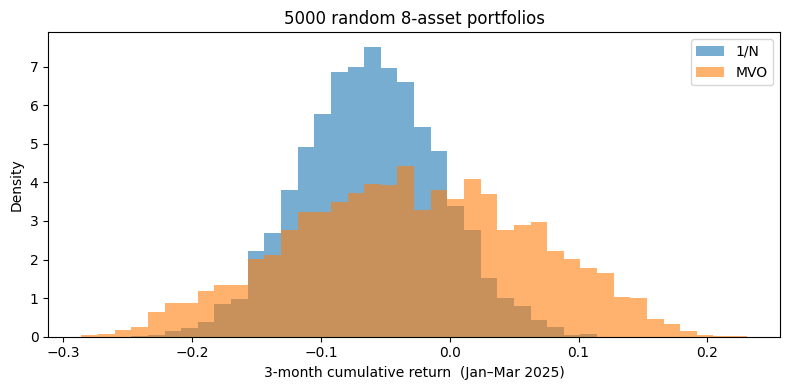

In [60]:
# ======================================================================
# Monte-Carlo comparison: equal-weight vs. Markowitz on random 8-asset subsets
# this approach is based on a comment of Pfof. Tiso in the forum of the course.
# ======================================================================


# ---------- user parameters -------------------------------------------
UNIVERSE  = TICKERS                 # the tickers created earlier
k         = 8                       # subset size
N_SIM     = 5000                    # Monte-Carlo replications
SEED      = 42                      # reproducibility
# ----------------------------------------------------------------------

rng = np.random.default_rng(SEED)
n_assets = len(UNIVERSE)

# ---------- storage for simulation results ----------------------------
ret_eq   = np.empty(N_SIM)
ret_mvo  = np.empty(N_SIM)

# ---------- turn training data into inputs for the optimiser ----------
mean_returns_train = returns_train.mean().values          # DAILY mean
Σ_train  = Sigma_shrinkage.values               # DAILY covariance

# ---------- Monte-Carlo loop ------------------------------------------
for sim in range(N_SIM):
    # draw subset
    subset_idx = rng.choice(n_assets, size=k, replace=False)
    subset_tkr = [UNIVERSE[i] for i in subset_idx]

    # slice mean & covariance  (still DAILY)
    mu_k = mean_returns_train[subset_idx]
    Σ_k  = Σ_train[np.ix_(subset_idx, subset_idx)]

    # equal-weight portfolio
    w_eq = np.full(k, 1/k)

    # Markowitz portfolio
    w_mvo = mvo_weights(mu_k, Σ_k, rf_mean_train, w_min, w_max)

    # compute TEST-window cumulative *simple* returns
    R_test  = returns_test[subset_tkr]
    cum_eq  = (1 + R_test @ w_eq ).prod() - 1
    cum_mvo = (1 + R_test @ w_mvo).prod() - 1

    ret_eq[sim]  = cum_eq
    ret_mvo[sim] = cum_mvo


# ---------- summary statistics ----------------------------------------
def stats(a):
    return pd.Series(
        {"mean": a.mean(), "std": a.std(), "sharpe": a.mean()/a.std(),
         "min": a.min(), "max": a.max(), "median": np.median(a)}
    )

summary = pd.concat({
    "1/N": stats(ret_eq),
    "MVO": stats(ret_mvo)
}, axis=1).round(4)

display(summary)

# ---------- histogram -------------------------------------------------
plt.figure(figsize=(8,4))
bins = np.histogram(np.hstack([ret_eq, ret_mvo]), bins=40)[1]
plt.hist(ret_eq,  bins=bins, alpha=0.6, label="1/N",   density=True)
plt.hist(ret_mvo, bins=bins, alpha=0.6, label="MVO", density=True)
plt.xlabel("3-month cumulative return  (Jan–Mar 2025)")
plt.ylabel("Density")
plt.title(f"{N_SIM} random {k}-asset portfolios")
plt.legend()
plt.tight_layout()
plt.show()


1/N portfolios are slightly worse than MVO.

# Step 4

## Views

### Material Sector
- Linde (LIN) – Absolute view. Q: ~+10%. Confidence: Medium. Justification: The company underperformed in 2024 but it is expected to improve in 2025, if the global economy improves. CNBC (Dec 27, 2024) noted Linde could return to its “beat-and-raise” earnings cadence with a stronger economy. The company ended Q3 2024 with a high record of backlos than it is a positive factor for growth. [https://www.cnbc.com/2024/12/27/a-pickup-in-the-global-economy-should-get-linde-back-to-its-winning-ways-in-2025.html]

- Air Products & Chemicals (APD) – Absolute view. Q: ~+15%. Confidence: Medium. Justification: A activist investor called Mantle Ridge took  more than $1B stake in APD in 2024, pushing for strategic changes (succession planning, capital allocation) to unlock value. The stock increased about 9% on the news in Oct 2024. With these catalysts, analysts expect improved efficiency and shareholder returns. [https://www.investopedia.com/air-products-stock-jumps-as-activist-investor-pushes-strategy-shift-8724566]

- Albemarle (ALB) – Absolute view. Q: ~+15%. Confidence: Medium (high upside, but commodity-driven). Justification: ALB’s shares were depressed in 2024 due to lower global lithium prices, but analysts anticipate a strong recovery due to the increasing demand for batteries. The average analyst target implies ~15-20% rise from late-2024 prices. [https://www.zacks.com/stock/quote/ALB]

### Communication Services
- Meta Platforms (META) – Absolute view. Q: ~+15%. Confidence: High. Justification: Meta’s AI and advertising momentum are creating a bullish forecasts. Multiple agencies have raised targets in Dec 2024 (e.g. JPMorgan to $725, Truist $700, Bernstein $675) as Meta’s earnings and user growth exceeded peers. Consensus calls for ~10–20% upside as Meta’s ad revenue and new AI features drive growth.[https://investorsobserver.com/news/meta-platforms-meta-stock-prediction-for-2025-betting-on-ai]

- Comcast (CMCSA) – Absolute view. Q: ~+5%. Confidence: Medium. Justification: Comcast lagged in 2024 (stock –13.6% vs S&P +25%), but for 2025 analysts are moderately bullish. The stock traded below the ~$48 average target, and consensus rating was Moderate Buy (17 Buy, 11 Hold). Strong growth and cost controls support a modest rebound. (https://www.nasdaq.com/articles/comcasts-q4-2024-earnings-what-expect)

- Fox Corp (FOXA) – Absolute view. Q: ~+5%. Confidence: Medium. Justification: Analysts' consensus rating on Fox Corporation’s stock is cautiously optimistic, with a “Moderate Buy" overall rating. Out of 20 analysts covering the stock, opinions include nine "Strong Buys" and 11 "Holds." The average analyst price target for FOXA is $47.65, which indicates that the stock trades at a premium. (https://www.nasdaq.com/articles/what-expect-fox-corporations-q2-2025-earnings-report)

- Alphabet/Google (GOOGL) – Absolute view. Q: ~+10%. Confidence: High. Justification: Google enjoyed the bull market of tech stocks in 2024 and the analysist expect a similar performance in 2025. Many studies show that the growth indicators are strong. Google is expected to benefit from the AI boom and the strong economy. (https://www.investors.com/news/technology/google-stock-buy-now-alphabet-stock-december-2024/)

Relative view – AAPL vs. MSFT: Microsoft to outperform Apple. Q: +~7% (MSFT over AAPL). Confidence: High. Justification: Microsoft is projected to grow revenue/EPS ~15% in 2024–25 vs. Apple’s ~6–8%. With its cloud infrastructure & OpenAI advantages and the Activision acquisition, MSFT has stronger catalysts. One analysis explicitly argues MSFT will outpace AAPL in 2025. Meanwhile Apple, though stable, doesn't have near-term drivers beyond usual services growth. (https://www.nasdaq.com/articles/will-microsoft-still-be-worth-more-than-apple-by-2025, https://schwabnetwork.com/video/2024-year-in-review-a-i-s-role-in-aapl-msft-nvda-)


### Energy Sector

- Exxon Mobil (XOM) – Absolute view. Q: ~+15%. Confidence: High. Justification: Despite a soft 2024, Exxon is expected to have a 'stronger year than 2024' in 2025, per analysts. Free cash flow remains very high (> \\$30B/yr), and a pro-fossil U.S. policy shift (new administration in 2025) could boost margins via deregulation. Consensus price targets around $124 imply ~16% upside. (https://www.nasdaq.com/articles/3-reasons-why-exxon-xom-set-excellence-2025)

- ConocoPhillips (COP) – Absolute view. Q: ~-10%. Confidence: Medium. Justification: COP shares are near the 52-week low, impacted by the supply chain issues. Despite the operational strength and increased production level, the analysists expect the challenging commodity price environment to persist into 2025. (https://seekingalpha.com/article/4746461-conocophillips-attractive-even-in-a-more-muted-commodity-price-environment)

- APA Corp (APA) – Absolute view. Q: ~-5%. Confidence: Medium-Low. Justification: In the APA third quarter 2024 the revenue increased by 10% from 3Q 2023 and the net loss reduced by 149% from 3Q 2023. The analisysts don't expect that the company will improve in 2025 very much despite the strong production level. (https://finance.yahoo.com/news/apa-third-quarter-2024-earnings-121345607.html)

- Chevron (CVX) – Absolute view. Q: ~-5%. Confidence: Medium. Justification: Chevron faces significant risks. Oil price volatility remains a key concern, as lower prices due to the global economy situation could affect the profit of the company. Geopolitical risks, particularly in regions like Kazakhstan, could also disrupt operations. (https://www.nasdaq.com/articles/chevrons-spending-shift-should-you-buy-stock-2025)

### Financials

- JPMorgan Chase (JPM) – Absolute view. Q: ~+7%. Confidence: Medium. Justification: After a ~40% stock uprising in 2024, it is expected to have modest gains. JPM’s profits are at record highs (Q4 2024 net income +30% YoY) and it consistently beat estimates, but with its valuation now higher, we can not expect a high return for 2025. (https://www.globenewswire.com/news-release/2024/11/18/2982958/28124/en/2024-J-P-Morgan-Private-Bank-Competitor-Profile-Key-Strategies-Financial-Performance-Customers-and-Products-Brand-Building-Activities.html, https://www.investopedia.com/what-analysts-think-of-jpmorgan-chase-stock-ahead-of-earnings-8771652)

- PNC Financial (PNC) – Absolute view. Q: ~+7%. Confidence: Medium. Justification: The banking industry in general has been preparing for a potential fallout from the higher-for-longer interest rate environment by increasing its loan loss provisions, anticipating that some borrowers may struggle to repay credit card, mortgage and other debt. Despite these challenges, PNC is expected to have modest gains in 2025. (https://www.investopedia.com/what-analysts-think-of-jpmorgan-chase-stock-ahead-of-earnings-8771652)

- Lincoln National (LNC) – Absolute view. Q: ~+5%. Confidence: Medium-Low. Justification: In the third quarter 2024, Lincoln National experienced a net loss of \\$528 million cpmpared to the prior-year quarter's net income of \\$853 million. The Life Insurance segment reported an operating income of \\$22 million against the year-ago quarter's loss of $173 million. We have a mix of different signals. We remain cautiously optimistic about the company's prospects for 2025, but we expect modest gains. (https://finance.yahoo.com/news/lincoln-national-q3-earnings-beat-184700902.html, https://www.businesswire.com/news/home/202411
01089053/en/Lincoln-National-Corporations-Board-of-Directors-Declares-Series-D-Preferred-Stock-Dividend)

- Berkshire Hathaway (BRK.B) - Absolute view. Q: ~+10%. Confidence: High. Justification: Berkshire Hathaway made some big moves in 2024 -- and it was mostly toward cash.The company bought a few new stocks but not in a significant amount. It seems that the Buffett is not optimistic about the market and is waiting for a bear market. This strategic decision is expected to pay off in the long run. We keep the stock in the portfolio for the mid-long term and expect even in 2025 we will see good news. (https://www.fool.com/investing/2024/12/08/cash-and-patience-berkshires-2024-moves-set-the/)

- Visa (V) - Absolute view. Q: +10%. Confidence: High. Justification: Visa's growth trend remains intact. The consensus rating is Strong Buy. There is no reason why the company will not continue making profit. For the 2024 results we have a revenue of US$35.9B  (up 10.0% from FY 2023) and net income: US\\$19.7b (up 16% from FY 2023) and profit margin: 55% (up from 52% in FY 2023). The increase in margin was driven by higher revenue.(https://finance.yahoo.com/news/visa-full-2024-earnings-line-130723645.html)

### Industrials

- Caterpillar (CAT) – Absolute view. Q: -5% (slight negative). Confidence: Medium. Justification: The macroeconomical conditions are challenging for heavy industry. Despite Caterpillar's strong production level, the analysists expect the challenging commodity price environment to persist into 2025. (https://finance.yahoo.com/news/caterpillar-cat-held-better-peers-141032055.html, https://www.forbes.com/sites/greatspeculations/2024/10/28/should-you-pick-caterpillar-stock-ahead-of-q3/)

- UPS (UPS) – Absolute view. Q: –5%. Confidence: Medium. Justification: UPS has a good strategy for a long term, but company now is behind his main competitor FedEx. The industry is under pressure in an oversupplied package delivery network. The pandemic threw a wrench into forecasting, and the industry overexpanded routes and capabilities in anticipation of sustained growth that never materialized. Throw in supply chain and inflation challenges in recent years, and it has been far from an easy time for these companies. (https://www.nasdaq.com/articles/fedex-outperformed-ups-2024-which-dividend-stock-better-buy-2025)

- Carrier Global (CARR) – Absolute view. Q: ~+5%. Confidence: High. Justification: HVAC giant Carrier Global reported worse-than-expected sales as the company moved to exit its Fire & Security business. This reported causes a drop in the stock price. This movement is still persistent but due to high quality portfolio transformation of the company and the strong revenue we believe that the company will will change the situation in the 2025 and the stock price will go up. (https://www.investopedia.com/carrier-global-stock-cools-on-soft-sales-guidance-cut-8733534)

- General Electric (GE) – Absolute view. Q: ~+15%. Confidence: High. Justification: Post-breakup, GE Aerospace is now the core of GE and it’s thriving. Looking into 2025 they expect a double-digit revenue and profit growth. All the indicators are pointing to a strong performance in 2025. (https://www.geaerospace.com/sites/default/files/geaerospace_webcast_pressrelease_01232025.pdf)

### Technology

- NVIDIA (NVDA) – Absolute view. Q: +20%. Confidence: Medium. Justification: NVIDIA had an explosive 2024 (AI chip demand). The demand for GPU is still very high and we don't see any real competitors in the market. Nvidia's data center revenue rose by a remarkable 112% year over year in the third quarter of its fiscal 2025 to a record \\$30.8 billion, while AMD's revenue from this segment came in at just \\$3.5 billion in its most recently reported quarter.(https://finance.yahoo.com/news/prediction-artificial-intelligence-ai-chip-130700235.html)

- Synopsys (SNPS) – Absolute view. Q: -5%. Confidence: Medium. Justification: The debts of the company is growing. This is a result of heavy investment of the company. Many investors are concerned about this debt level. Synopsys has boosted its EBIT by 33%, thus reducing the spectre of future debt repayments. The company has has net cash of US\\$1.98b. The cherry on top was that in converted 111% of that EBIT to free cash flow, bringing in US$998m. Despite this positive numbers, still the cost of capital is high and the company is not profitable enough. (https://simplywall.st/stocks/us/software/nasdaq-snps/synopsys/news/is-synopsys-nasdaqsnps-using-too-much-debt-2, https://www.design-reuse.com/news/57149/synopsys-2024-financial-results.html)

- Zscaler (ZS) – Absolute view. Q: -10%. Confidence: Low. Justification: Zero-trust security vendor Zscaler overwhelmed in 2024 and the company is not profitable enough. The competitors are strong and maybe the company will not be able to catch up with them. (https://www.investors.com/news/technology/zscaler-stock-zscaler-earnings-q32024/)

- Apple (AAPL) – Absolute view. Q: +8%. Confidence: Medium. Justification: Apple's stock is expected to grind higher at a modest rate. FY2024–25 consensus calls for single-digit growth. Without a major new product until Vision Pro (late 2024), Apple lacks catalysts – reflected in its ~ 28x P/E limiting upside. Thus, we expect a modest positive excess return. (https://www.nasdaq.com/articles/will-microsoft-still-be-worth-more-than-apple-by-2025#:~:text=dipped%203,flat%20for%20the%20full%20year)

- Microsoft (MSFT) – Absolute view. Q: +15%. Confidence: High. Justification: Microsoft is having a good results in different sectors. Analysts project 15% EPS growth in FY2024 and FY2025. The stock’s valuation (≈ 35×) is higher, but deemed justified by its stronger growth. Overall confidence is high due to MSFT’s leadership in AI and diversified revenue streams such as gaming and cloud computing. (https://www.nasdaq.com/articles/will-microsoft-still-be-worth-more-than-apple-by-2025#:~:text=dipped%203,flat%20for%20the%20full%20year)

### Consumer Staples

- Procter & Gamble (PG) – Absolute view. Q: +10%. Confidence: Medium. Justification: P&G is a defensive stalwart with modest growth. With steady consumer demand and easing commodity costs, P&G should deliver a roughly high-single-digit return, in line with its earnings growth plus dividend. (https://www.investing.com/news/insider-trading-news/procter--gambles-chief-hr-officer-sells-22-million-in-stock-93CH-3739659)

- Kimberly-Clark (KMB) – Absolute view. Q: ~ +5%. Confidence: Medium. Justification: The maker of Huggies and Kleenex is viewed as fairly valued. Consensus 12-month target ~ 3.5% dividend and low-single-digit sales growth yielding modest total return. In short, we expect a stable but unexciting outlook. (https://www.marketbeat.com/originals/dividend-king-kimberly-clark-is-a-good-buy-in-2025/#:~:text=Dividend%20King%20Kimberly,upside%20this)

- Molson Coors (TAP) – Absolute view. Q: ~ +5%. Confidence: Medium. Justification: Analysts have mixed views (5 Buy, 6 Hold). That modest upside reflects stable beer demand but few catalysts. (https://www.nasdaq.com/articles/where-molson-coors-beverage-stands-analysts#:~:text=Analysts%20provide%20deeper%20insights%20through,50)

- Costco (COST) – Absolute view. Q: ~ +8%. Confidence: Medium. Justification: Costco continues to be a steady “compounder.” Morgan Stanley called it “among the best” retailers (https://www.investopedia.com/what-you-need-to-know-ahead-of-costco-earnings-thursday-q4-fy-2024-earnings-preview-8715769#:~:text=What%20You%20Need%20To%20Know,among%20the%20best%20compounding)

### Utilities

- NextEra Energy (NEE) – Absolute view. Q: ~ +15%. Confidence: Medium. Justification: After a 2024 sell-off (clean energy stocks hit by higher rates), NEE has significant rebound potential. (https://www.nasdaq.com/articles/examining-future-nextera-energys-earnings-outlook#:~:text=Nasdaq%20www,33%20implies%20a)


- Duke Energy (DUK) – Absolute view. Q: ~ +8%. Confidence: High. Justification: Duke is a regulated utility with a predictable outlook. The only issue that we see is the debt level of the company which concerns some investors. (https://simplywall.st/stocks/us/utilities/nyse-duk/duke-energy/news/duke-energy-nyseduk-has-a-somewhat-strained-balance-sheet-2)


- AES Corp (AES) – Absolute view. Q: ~ -10%. Confidence: Medium-Low. Justification: AES’s stock decreased ~ –30% in 2024, but some analysts anticipate a partial rebound which we are not sure about it. (https://www.nasdaq.com/articles/aes-corporation-stock-outlook-wall-street-bullish-or-bearish)

### Health Care

-   UnitedHealth Group (UNH) – Absolute view. Q: ~+10%. Confidence: Medium. Justification: UNH shares pulled back in 2024 on healthcare cost concerns, but the stock remains very bullish. (https://www.unitedhealthgroup.com/content/dam/UHG/PDF/investors/2025/UNH-Reports-Q1-2025-Results-Revises-Full-Year-Guidance.pdf)

- Medtronic (MDT) – Absolute view. Q: ~+5%. Confidence: Medium. Justification: Medtronic is in recovery mode from the previous losses with new product launches. The profit is expected to grow by 15% in 2025 (https://simplywall.st/stocks/us/healthcare/nyse-mdt/medtronic/news/medtronic-nysemdt-is-posting-promising-earnings-but-the-good)

- Baxter International (BAX) – Absolute view. Q: ~+5%. Confidence: Medium. Justification: Baxter underwent restructuring in 2024. Maybe we see a rebound in 2025. There is a challenging outlook for all the sector in 2025 due to high cost of health system. The company maintain a "good" financial health score (https://www.investing.com/news/company-news/baxter-stock-touches-52week-low-at-316-amid-market-challenges-93CH-3764142)

- Eli Lilly (LLY) – Absolute view. Q: ~+20%. Confidence: Medium. Justification: Lilly’s transformative obesity and Alzheimer’s drugs led to massive gains in 2023. Many analysts see this company undervaluated and expect a rebound in 2025. (https://www.nasdaq.com/articles/eli-lilly-undervalued-growth-stock-buy-now)

### Consumer Discretionary

- Amazon.com (AMZN) – Absolute view. Q: ~+20%. Confidence: High. Justification: Amazon’s cloud and retail businesses are reaccelerating after a cost efficiency drive. The stock prices all near historic high. We dont see any reason for not expect continue this trend in 2025. (https://www.ig.com/en/news-and-trade-ideas/amazon-share-price-analysis--what-lies-ahead-for-the-tech-giant--241126)

- Nike (NKE) – Absolute view. Q: ~+5%. Confidence: Low. Justification: Nike surprised the market with a strong Q4 earnings report and guidance for Q1 2025. Nike's EPS of $0.78 exceeded forecasts by approximately 20%. But there are many market challenges that affectd negatively the revenue. So we see a mix signal. (https://www.investing.com/news/transcripts/earnings-call-transcript-nike-q2-2024-beats-eps-forecasts-stock-rises-93CH-3783503)

- Etsy (ETSY) – Absolute view. Q: ~-5%. Confidence: Low. Justification: Etsy is struggling with post-pandemic crisis – directors informed the Q1 2025 gross merchandise sales probably will decline again like Q4 2024. (https://finance.yahoo.com/news/why-etsy-inc-nasdaq-etsy-120237563.html)

- Tesla (TSLA) – Absolute view. Q: ~-10%. Confidence: Medium. Justification: Tesla's CEO is actively participating in the political discussions and this is a risk for the company. New chinese car markers are growing fast and the market share  of the company is shrinking. The company is not profitable enough and the debt level is growing. (https://www.morningstar.co.uk/uk/news/258640/is-tesla-stock-a-buy-or-sell-after-massive-post-election-surge-.aspx)


### Real Estate

- Prologis (PLD) – Absolute view. Q: -5%. Confidence: Medium. Justification: Prologis, the largest logistics REIT, is expected to deliver modest upside. PLD is underperforming the real estate sector compared to the rivals. (https://www.nasdaq.com/articles/prologis-stock-pld-underperforming-real-estate-sector)

- American Tower (AMT) – Absolute view. Q: ~+5%. Confidence: Medium. Justification: Tower REITs like AMT faced pressure from high rates and tenant mergers in 2024. But due to surge of 5G still the demand is relatively strong for the company. (https://finance.yahoo.com/news/american-tower-stock-falls-16-163900699.html)

- AvalonBay Communities (AVB) – Absolute view. Q: ~+5%. Confidence: Medium. Justification: AvalonBay Communities is a multifamily residential REIT that specializes in upscale apartment communities. The same situation as the two previous companies here. The sector is struggeling due to high intrest rates and the demand for the apartments is decreasing. (https://money.usnews.com/investing/articles/best-real-estate-stocks-to-buy)

The above views can be used to construct the `P` matrix that reflects the opinions of the portfolio manager.

## Calculations

In [61]:

# ---------------------------------------------------------------
# 1. absolute-view table  (ticker,  Q,  conf)
# ---------------------------------------------------------------
abs_table = [
    ("LIN",      +0.10, "med"),
    ("APD",      +0.15, "med"),
    ("ALB",      +0.15, "med"),
    ("META",     +0.15, "high"),
    ("CMCSA",    +0.05, "med"),
    ("FOXA",     +0.05, "med"),
    ("GOOGL",    +0.10, "high"),
    ("XOM",      +0.15, "high"),
    ("COP",      +0.10, "med"),
    ("APA",      +0.05, "low"),
    ("CVX",      +0.05, "med"),
    ("JPM",      +0.07, "med"),
    ("PNC",      +0.07, "med"),
    ("LNC",      +0.05, "low"),
    ("BRK-B",    +0.10, "low"),
    ("V",        +0.10, "high"),
    ("CAT",      -0.05, "med"),
    ("UPS",      -0.05, "med"),
    ("CARR",     +0.05, "high"),
    ("GE",       +0.15, "high"),
    ("NVDA",     +0.20, "med"),
    ("SNPS",     -0.05, "high"),
    ("ZS",       -0.10, "low"),
    ("AAPL",     +0.08, "med"),
    ("MSFT",     +0.15, "high"),
    ("PG",       +0.10, "med"),
    ("KMB",      +0.05, "med"),
    ("TAP",      +0.05, "med"),
    ("COST",     +0.08, "med"),
    ("NEE",      +0.15, "med"),
    ("DUK",      +0.08, "high"),
    ("AES",      -0.10, "low"),
    ("UNH",      +0.10, "med"),
    ("MDT",      +0.05, "med"),
    ("BAX",      +0.05, "med"),
    ("LLY",      +0.20, "med"),
    ("AMZN",     +0.20, "high"),
    ("NKE",      +0.05, "med"),
    ("ETSY",     -0.05, "low"),
    ("TSLA",     -0.10, "low"),
    ("PLD",      -0.08, "med"),
    ("AMT",      +0.05, "med"),
    ("AVB",      +0.05, "med"),
    ("GC=F",     +0.25, "low"),
    ("BTC-USD",  +0.20, "low"),
]

# ---------------------------------------------------------------
# 2. relative-view table  ((long,short), Q, conf)
# ---------------------------------------------------------------
rel_table = [
    (("MSFT","AAPL"),   +0.07, "high"),   # tech giants
    (("TSLA","AMZN"),   +0.05, "med"),    # EV vs e-commerce
    (("XOM","PG"),      +0.08, "high"),   # energy > staples
]

In [62]:


def var_linear_combo(weights, Σ):
    # compute variance of linear combo of assets
    return weights @ Σ @ weights

conf_scale = {"high":0.1, "med":0.3, "low":1.0}
ticker_index = {t:i for i,t in enumerate(TICKERS)}


# ---------------------------------------------------------------
# 3. build P, Q, Omega
# ---------------------------------------------------------------
n = len(TICKERS)
tau = 1 / returns_train.shape[0]      # following He–Litterman τ
P_rows, Q_list, Omega_diag = [], [], []

# --- absolute views
for tic, q, conf in abs_table:
    row = np.zeros(n)
    row[ticker_index[tic]] = 1
    P_rows.append(row)
    Q_list.append(q)
    var_i = Sigma_shrinkage.loc[tic, tic]
    Omega_diag.append(tau * var_i / conf_scale[conf]**2)

# --- relative views
for (long_tic, short_tic), q, conf in rel_table:
    row = np.zeros(n)
    i, j = ticker_index[long_tic], ticker_index[short_tic]
    row[i], row[j] = +1, -1
    P_rows.append(row)
    Q_list.append(q)
    var_pair = (Sigma_shrinkage.iloc[i,i] +
                Sigma_shrinkage.iloc[j,j] -
                2*Sigma_shrinkage.iloc[i,j])
    Omega_diag.append(tau * var_pair / conf_scale[conf]**2)

P      = np.vstack(P_rows)
Q      = np.array(Q_list)
Omega  = np.diag(Omega_diag)

print(f"Shape of P: {P.shape}")
print(f"Shape of Q: {Q.shape}")
print(f"Shape of Omega: {Omega.shape}")

Shape of P: (48, 45)
Shape of Q: (48,)
Shape of Omega: (48, 48)


In [63]:
"""
calculate market weights as the prior distribution of expected returns
we are calculating these values live, so we can use the latest market cap, not the historical one
at the time of portfolio construction.
"""

def get_live_mkt_caps(tickers):
    """
    Retrieves the latest market capitalization for the given tickers.
    If the result is already cached, return the cached value.
    Otherwise, retrives from Yahoo Finance for each ticker and cache the result.
    """
    p_path = CACHE_DIR / f"market_caps_{TRAIN_START}_{TRAIN_END}.parquet"
    if p_path.exists():
        return pd.read_parquet(p_path)["market_cap"]

    caps = {}
    for t in tickers:
        info = yf.Ticker(t).info
        caps[t] = info.get("marketCap")

    caps = pd.Series(caps, dtype="float64", name="market_cap")
    caps.to_frame().to_parquet(p_path)
    return caps


mkt_caps_now = get_live_mkt_caps(TICKERS)

# market cap of the gold and bitcoin are huge and we need to correct them manually.
mkt_caps_now["GC=F"]     = 600_000_000_000     # GLD AUM ETF
mkt_caps_now["BTC-USD"] = 200_000_000_000      # BITO AUM ETF

market_weights = mkt_caps_now / mkt_caps_now.values.sum()
market_weights = market_weights.reindex(Sigma_shrinkage.columns)


delta = black_litterman.market_implied_risk_aversion(prices_train)
prior = black_litterman.market_implied_prior_returns(market_weights, delta, Sigma_shrinkage)

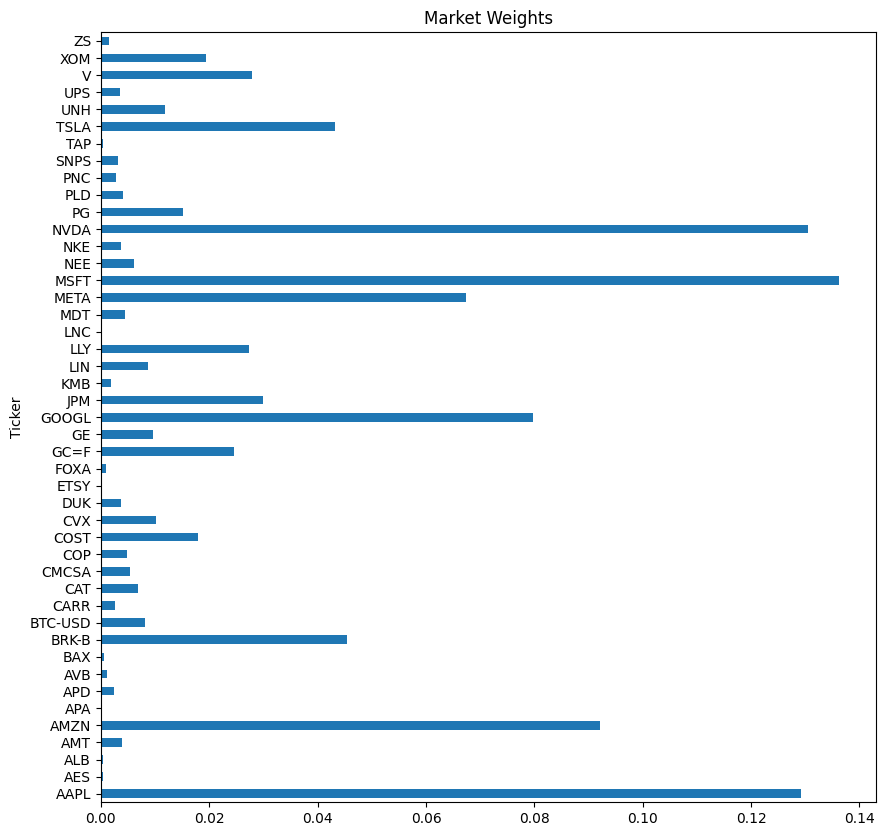

In [64]:
market_weights.plot.barh(figsize=(10, 10))
plt.title("Market Weights")
plt.show()

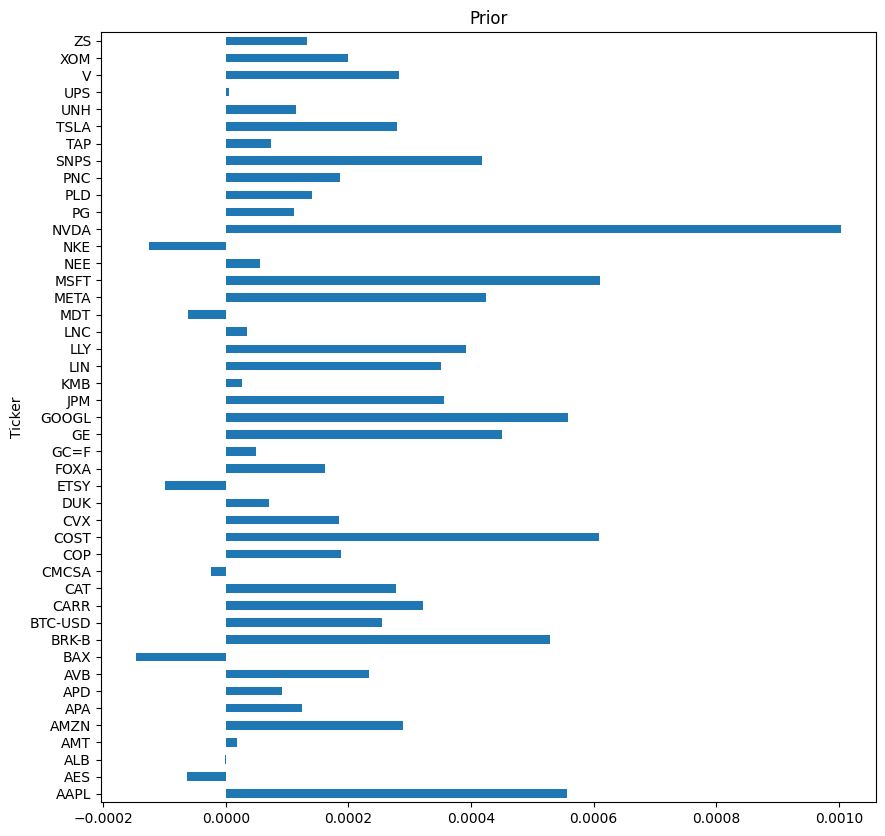

In [65]:
prior.plot.barh(figsize=(10,10));
plt.title("Prior")
plt.show()


Because $(\Sigma w)_i$ is the covariance of asset $i$ with the cap-weighted market portfolio, the sign depends on the asset’s beta:

- Positive beta $\rightarrow$ positive $\Pi_i$ (asset expected to earn a positive excess return over the risk-free rate).
- Negative or very low beta $\rightarrow$ zero or negative $\Pi_i$ (CAPM says it should earn less than the risk-free rate because it hedges the market).

So negative securities are not an error; they simply indicate assets that reduce portfolio volatility (low/negative beta) and therefore carry a lower equilibrium reward.

In [66]:
# ---------------------------------------------------------------
# Black-Litterman with custom P,Q,Ω
# ---------------------------------------------------------------

bl = BlackLittermanModel(
        Sigma_shrinkage,
        pi = prior,
        tau = tau,
        P = P,
        Q = Q,
        omega = Omega,
)

mu_bl     = bl.bl_returns()
Sigma_bl  = bl.bl_cov()


Let's evaluate the performance of the portfolio constructed by means of Black-Litterman model and compare it with the previous

In [67]:
def prune_weights(w, floor=0.01):
    """Set weights < floor to 0, renormalise."""
    mask = w < floor
    w = w.copy()
    w[mask] = 0
    w /= w.sum()
    return w


# ================================================================
#   Convert BL posterior objects to NumPy
# ================================================================
mu_bl_vec = mu_bl.values
Sigma_bl_mat = Sigma_bl.values

# ================================================================
#   Optimise Black-Litterman posterior
# ================================================================
rf_daily_scalar = rf_daily_train.mean()

weights_bl = mvo_weights(mu_bl_vec, Sigma_bl_mat, rf_daily_scalar, w_min, w_max)
weights_bl = prune_weights(weights_bl, floor=0.01)   # 1 %
weights_bl = pd.Series(weights_bl, index=TICKERS, name="BL")

# -------------------------------------------------
#   side-by-side weight comparison
# -------------------------------------------------
all_weights = pd.concat(
    [weights_sample.rename("MVO_Σsample"),
     weights_shrinkage.rename("MVO_Σshrink"),
     weights_bl.round(4)],
    axis=1
).round(4)

print("=== Weight vectors ===")
display(all_weights.style.format("{:.3f}"))

=== Weight vectors ===


,MVO_Σsample,MVO_Σshrink,BL
LIN,0.000,0.000,0.000
APD,0.000,0.000,0.000
ALB,0.000,0.000,0.000
META,0.000,0.000,0.000
CMCSA,0.000,0.000,0.000
FOXA,0.000,0.000,0.000
GOOGL,0.000,0.000,0.000
XOM,0.000,0.000,0.000
COP,0.000,0.000,0.040
APA,0.000,0.000,0.000


In [68]:
filtered_weights = all_weights[(all_weights > 0.00).any(axis=1)]
filtered_weights

,MVO_Σsample,MVO_Σshrink,BL
COP,0.000,0.000,0.0402
PNC,0.000,0.000,0.0151
V,0.107,0.109,0.0000
CAT,0.000,0.000,0.1776
GE,0.000,0.000,0.0133
NVDA,0.103,0.097,0.1691
SNPS,0.079,0.082,0.0000
MSFT,0.000,0.000,0.0584
KMB,0.347,0.346,0.0444
COST,0.000,0.000,0.0319


In [69]:
# Call the function
save_df_as_image(filtered_weights, "filtered_weights.png")

# dfi.export(filtered_weights, 'filtered_weights.png')

files.download('filtered_weights.png')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [70]:


# ================================================================
#   Performance evaluation
# ================================================================
def port_stats(w, rets, rf_daily):
    excess = rets.sub(rf_daily, axis=0) @ w
    tot    = rets @ w
    μ = excess.mean()*252
    σ = tot.std()*np.sqrt(252)
    sharpe = μ/σ
    return pd.Series([μ, σ, sharpe], index=["μ_ann","σ_ann","Sharpe"])

perf_train = pd.concat({
    "MarkovΣshrink": port_stats(weights_shrinkage, returns_train, rf_daily_train),
    "BL": port_stats(weights_bl, returns_train, rf_daily_train)
}, axis=1).round(3)

perf_test  = pd.concat({
    "MarkovΣshrink": port_stats(weights_shrinkage, returns_test, rf_daily_test),
    "BL": port_stats(weights_bl, returns_test, rf_daily_test)
}, axis=1).round(3)

print("\n=== In-sample (2021-24) ===")
display(perf_train)

print("\n=== Out-of-sample (Jan–Mar 2025) ===")
display(perf_test)





=== In-sample (2021-24) ===


,MarkovΣshrink,BL
μ_ann,0.071,0.185
σ_ann,0.129,0.169
Sharpe,0.553,1.094



=== Out-of-sample (Jan–Mar 2025) ===


,MarkovΣshrink,BL
μ_ann,0.185,0.033
σ_ann,0.175,0.242
Sharpe,1.059,0.135


In [71]:
# ================================================================
#   Risk-contribution breakdown
# ================================================================
rc_bl = contrib_to_risk(weights_bl, Sigma_shrinkage)
rc_cmp = pd.concat({
    "MarkovΣshrink": contrib_to_risk(weights_shrinkage, Sigma_shrinkage),
    "BL": rc_bl
}, axis=1).mul(100)

print("\n=== % Contribution to portfolio variance (train Σ) ===")
display(rc_cmp.round(1).style.format("{:.1f}%"))


=== % Contribution to portfolio variance (train Σ) ===


,MarkovΣshrink,BL
AAPL,0.0%,0.0%
AES,0.0%,0.0%
ALB,0.0%,0.0%
AMT,0.0%,0.0%
AMZN,0.0%,0.0%
APA,0.0%,0.0%
APD,0.0%,0.0%
AVB,0.0%,1.9%
BAX,0.0%,0.0%
BRK-B,0.0%,0.0%


In [72]:
filtered_rc = rc_cmp[(rc_cmp > 0.00).any(axis=1)]
filtered_rc

,MarkovΣshrink,BL
AVB,0.000000,1.943283
BTC-USD,0.000000,11.207633
CAT,0.000000,18.871437
COP,0.000000,3.057435
COST,0.000000,2.135207
GC=F,9.453311,12.876433
GE,0.000000,1.195120
KMB,28.655398,0.444759
MDT,11.083692,0.000000
MSFT,0.000000,5.740699


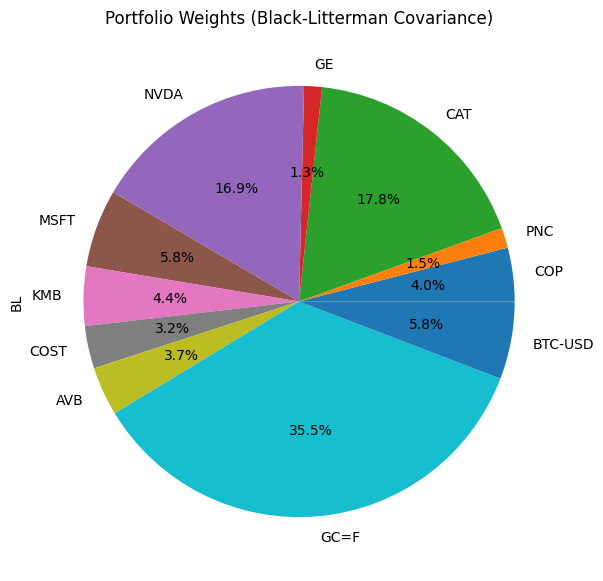

In [73]:
weights_bl[weights_bl > 0].plot.pie(figsize=(7,7), autopct='%1.1f%%');
plt.title("Portfolio Weights (Black-Litterman Covariance)")
plt.show()

The performance of our portfolio is not as expected. In fact, since the beggining of the year 2025 due to the tarrif policies of the US government, the financial market has been very volatile and unstable.  Somehow, we are expriencing a regime shift in the market. So, the importance of the historical data on the future performance of the portfolio is reduced.

## Step5 :Kelly Criterion

In [74]:

# Dummy return and covariance data to illustrate; replace with real data
# Example: from your previous context use `returns_train`, `returns_test`, `rf_daily_train`

# Let's assume we have these from your Black-Litterman and historical data setup
mu = returns_train.mean()  # Daily mean returns
Sigma = returns_train.cov()  # Covariance matrix
rf = rf_daily_train.mean()  # Daily risk-free rate

# Convert to numpy arrays
mu_vec = mu.values
Sigma_mat = Sigma.values

# -------------------------------
# Kelly optimal weights
# -------------------------------
# Excess returns
excess_mu = mu_vec - rf

# Full Kelly weights
kelly_weights = np.linalg.inv(Sigma_mat) @ excess_mu

# Normalize to sum to 1 (optional for interpretability)
kelly_weights_normalized = kelly_weights / np.sum(np.abs(kelly_weights))

# Convert to Series for readability
kelly_weights_series = pd.Series(kelly_weights_normalized, index=mu.index, name="Kelly")

# Prune small weights (e.g., < 1%)
kelly_weights_series = kelly_weights_series.where(np.abs(kelly_weights_series) > 0.01, 0)
kelly_weights_series /= kelly_weights_series.sum()

# Show the weights
kelly_weights_series.sort_values(ascending=False).round(4)


,Kelly
Ticker,
XOM,0.9420
BRK-B,0.4319
LLY,0.3396
DUK,0.3367
COST,0.3298
NVDA,0.3176
AVB,0.2992
GOOGL,0.2492
GE,0.2372


In [75]:
# Step 4: Convert to Series and prune small weights
kelly_series = pd.Series(kelly_weights, index=mu.index, name='Kelly')
kelly_series = kelly_series.where(np.abs(kelly_series) > 0.01, 0)
kelly_series /= kelly_series.sum()  # Re-normalize

# Final Kelly portfolio weights
kelly_series.round(4).sort_values(ascending=False)

,Kelly
Ticker,
XOM,0.8501
BRK-B,0.3897
LLY,0.3064
DUK,0.3038
COST,0.2976
NVDA,0.2866
AVB,0.2700
GOOGL,0.2249
GE,0.2140


In [76]:
kelly_series[kelly_series != 0].round(4).sort_values(ascending=False)


,Kelly
Ticker,
XOM,0.8501
BRK-B,0.3897
LLY,0.3064
DUK,0.3038
COST,0.2976
NVDA,0.2866
AVB,0.2700
GOOGL,0.2249
GE,0.2140


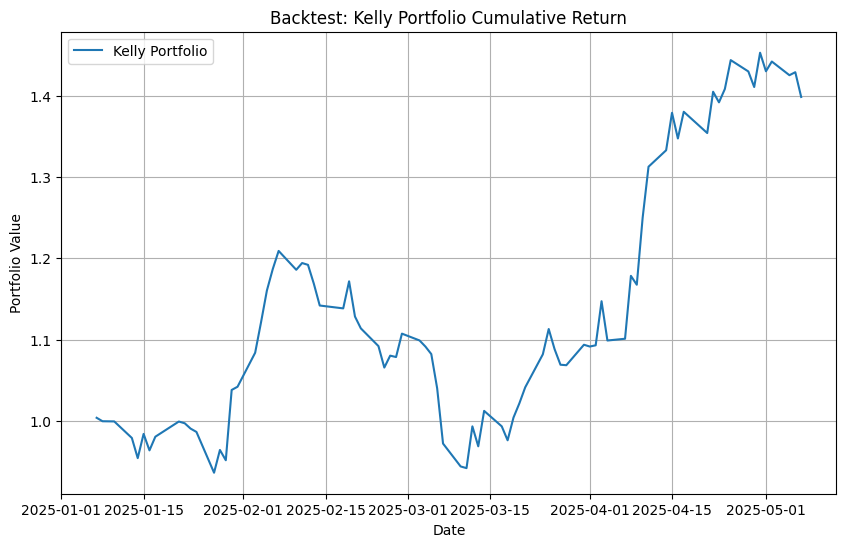

In [77]:
# Apply weights to test return data
kelly_returns = (returns_test @ kelly_series).dropna()

# Cumulative return
cumulative_return = (1 + kelly_returns).cumprod()

# Plot cumulative return
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(cumulative_return, label='Kelly Portfolio')
plt.title("Backtest: Kelly Portfolio Cumulative Return")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()


In [78]:
def performance_stats(returns, rf=0.0):
    ann_return = returns.mean() * 252
    ann_vol = returns.std() * np.sqrt(252)
    sharpe = (ann_return - rf * 252) / ann_vol
    total_return = (1 + returns).prod() - 1
    return pd.Series({
        "Ann. Return": ann_return,
        "Ann. Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Total Return": total_return
    })
# Apply weights to test return data
kelly_port_returns = (returns_test @ kelly_series).dropna()

# Cumulative wealth over time
kelly_cum_return = (1 + kelly_port_returns).cumprod()


kelly_stats = performance_stats(kelly_port_returns, rf=rf_daily_train.mean())
print(kelly_stats.round(4))


Ann. Return        1.1199
Ann. Volatility    0.4516
Sharpe Ratio       2.4123
Total Return       0.3985
dtype: float64


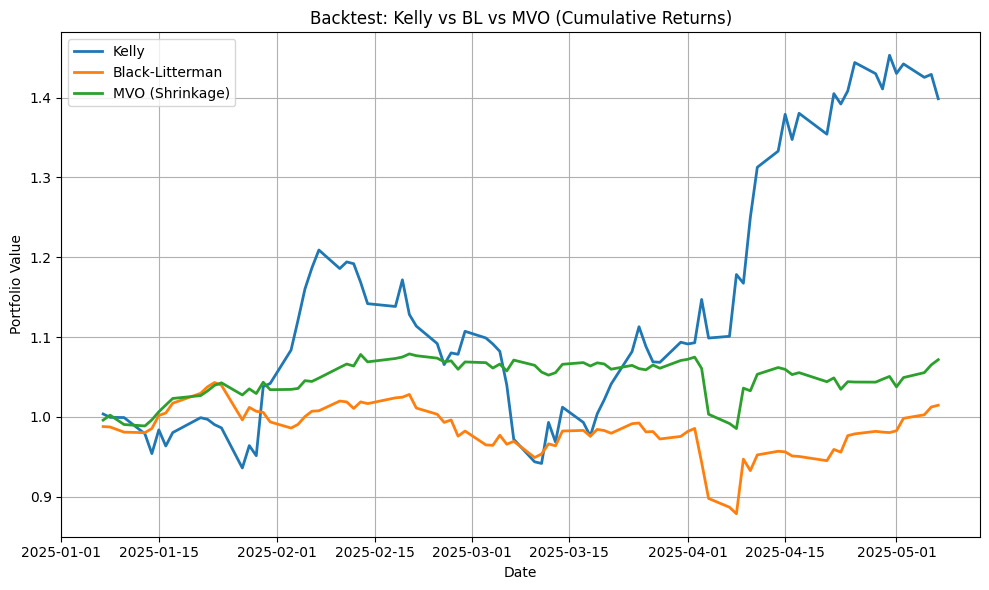

In [79]:


# Assume you have these already defined:
# - kelly_port_returns
# - weights_bl (Black-Litterman weights)
# - weights_shrinkage (MVO weights using shrinkage covariance)
# - returns_test

# Compute cumulative returns for MVO and BL
returns_bl = (returns_test @ weights_bl).dropna()
returns_mvo = (returns_test @ weights_shrinkage).dropna()

cum_kelly = (1 + kelly_port_returns).cumprod()
cum_bl = (1 + returns_bl).cumprod()
cum_mvo = (1 + returns_mvo).cumprod()

# Plot comparison
plt.figure(figsize=(10, 6))
plt.plot(cum_kelly, label='Kelly', linewidth=2)
plt.plot(cum_bl, label='Black-Litterman', linewidth=2)
plt.plot(cum_mvo, label='MVO (Shrinkage)', linewidth=2)
plt.title('Backtest: Kelly vs BL vs MVO (Cumulative Returns)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Rolling-Window Fractional Kelly(0.5) Backtest (with rebalancing)

Re-estimates Kelly weights every N days ( 21)

Applies weights to the next N days

Accumulates portfolio value over time
Plot the growth


In [80]:
# Configuration
window_size = 252  # use 1 year of history for each Kelly re-estimate
rebalance_freq = 21  # rebalance every month (21 trading days)
fraction = 0.5       # fractional Kelly for stability

# Initialize portfolio value
portfolio_value = [1.0]
dates = []
all_returns = []

# Align returns and rf
rf_daily = rf_daily_train.reindex(returns_test.index, method='ffill')

# Loop over test set in chunks
for start in range(0, len(returns_test) - rebalance_freq, rebalance_freq):
    # Define rebalancing window
    rebalance_date = returns_test.index[start]
    dates.append(rebalance_date)

    # Use training data ending at rebalance_date
    # train_end_idx = returns_train.index.get_loc(rebalance_date, method='ffill')
    train_end_idx = returns_train.index.get_indexer([rebalance_date], method='ffill')[0]

    returns_window = returns_train.iloc[train_end_idx - window_size:train_end_idx]
    rf_window = rf_daily_train.iloc[train_end_idx - window_size:train_end_idx]

    # Estimate Kelly weights
    mu = returns_window.mean()
    Sigma = returns_window.cov()
    rf = rf_window.mean()
    excess_mu = mu - rf
    kelly_raw = np.linalg.inv(Sigma) @ excess_mu.values
    kelly_weights = kelly_raw / np.sum(np.abs(kelly_raw))
    kelly_series = pd.Series(kelly_weights, index=mu.index)
    kelly_series = kelly_series.where(np.abs(kelly_series) > 0.01, 0)
    kelly_series /= kelly_series.sum()
    kelly_series *= fraction  # apply fractional Kelly

    # Apply weights to next rebalance_freq days
    test_chunk = returns_test.iloc[start:start+rebalance_freq]
    weighted_returns = test_chunk @ kelly_series
    all_returns.append(weighted_returns)

# Concatenate all periods
kelly_roll_returns2 = pd.concat(all_returns)
kelly_roll_cum2 = (1 + kelly_roll_returns2).cumprod()


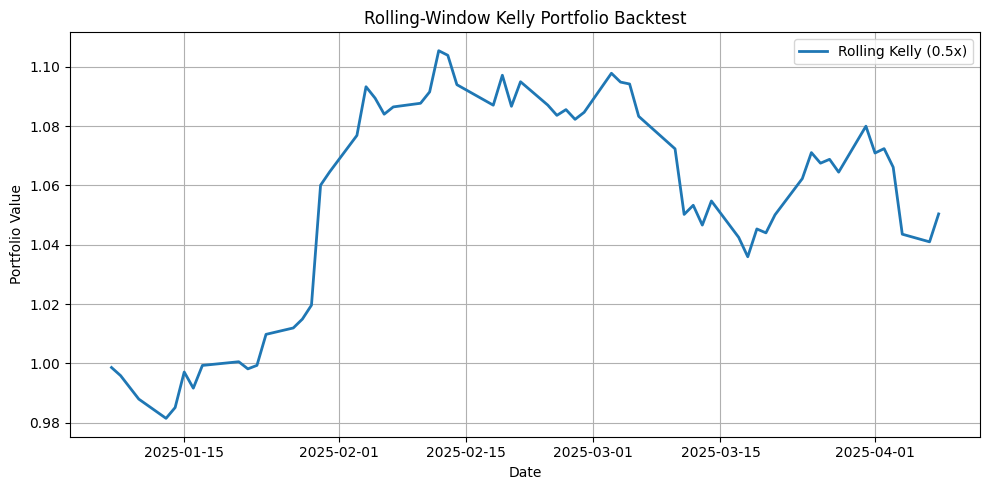

In [81]:

plt.figure(figsize=(10, 5))
plt.plot(kelly_roll_cum2, label='Rolling Kelly (0.5x)', linewidth=2)
plt.title("Rolling-Window Kelly Portfolio Backtest")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## Fractional kelly with rebalancing has different output than normal full kelly.
## Full kelly is best..